In [20]:
import pandas as pd
import matplotlib.pyplot as plt
import json

In [ ]:
df = pd.read_csv("replay_csvs/master_replays.csv")

# define rank groupings to start
beginner = ["bronze-1", "bronze-2", "bronze-3", "silver-1", "silver-2", "silver-3", "gold-1", "gold-2", "gold-3"]
intermediate = ["platinum-1", "platinum-2", "platinum-3", "diamond-1", "diamond-2", "diamond-3"]
expert = ["champion-1", "champion-2", "champion-3", "grand-champion-1", "grand-champion-2", "grand-champion-3", "supersonic-legend"]

In [ ]:
#labeling rows
df["group"] = "unknown"
df.loc[df["rank"].isin(beginner), "group"] = "Beginner"
df.loc[df["rank"].isin(intermediate), "group"] = "Intermediate"
df.loc[df["rank"].isin(expert), "group"] = "Expert"

In [25]:
#grabbing stats wanted and getting averages by group
stats = ["time high in air", "avg speed", "percentage on ground",
         "amount used while supersonic", "percentage offensive third",
         "time supersonic speed", "avg powerslide time", "percentage behind ball"]

#removes unwanted unknown rank data
filtered = df[df["group"] != "unknown"]
averages = filtered.groupby("group")[stats].mean()
print(averages)

              time high in air    avg speed  percentage on ground  \
group                                                               
Beginner              7.050683  1324.022779             64.350137   
Expert               15.491805  1536.426036             55.468994   
Intermediate          8.823390  1418.352740             62.304075   

              amount used while supersonic  percentage offensive third  \
group                                                                    
Beginner                        243.958998                   22.857540   
Expert                          277.526627                   21.035947   
Intermediate                    252.130137                   21.484623   

              time supersonic speed  avg powerslide time  \
group                                                      
Beginner                  21.034009             0.257813   
Expert                    48.511627             0.114112   
Intermediate              30.228767        

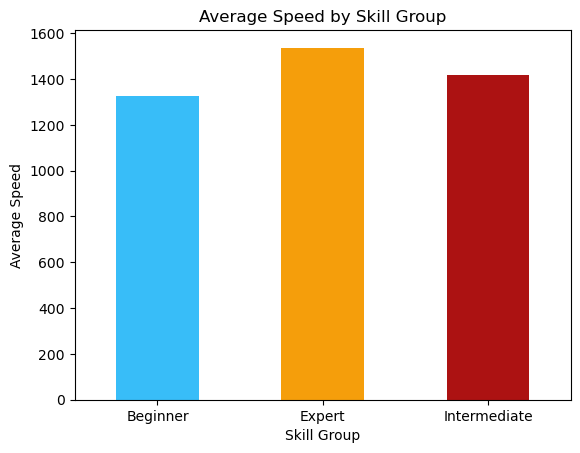

In [ ]:
#making avg speed bar graph to see information
averages["avg speed"].plot(kind="bar", color=["#38bdf8", "#f59e0b", "#ac1212"])
plt.title("Average Speed by Skill Group")
plt.ylabel("Average Speed")
plt.xlabel("Skill Group")
plt.xticks(rotation=0)
plt.show()

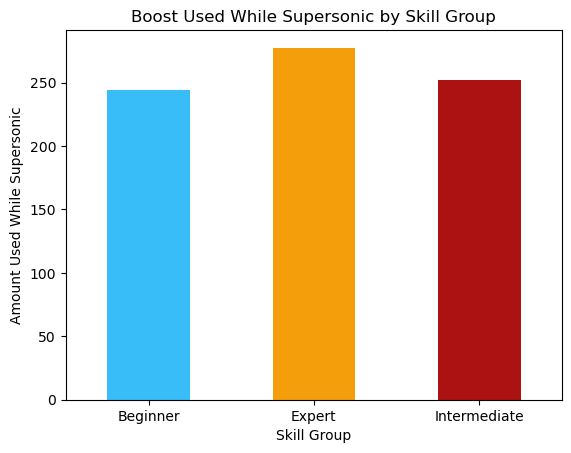

In [28]:
#making supersonic bar graph
averages["amount used while supersonic"].plot(kind="bar", color=["#38bdf8", "#f59e0b", "#ac1212"])
plt.title("Boost Used While Supersonic by Skill Group")
plt.ylabel("Amount Used While Supersonic")
plt.xlabel("Skill Group")
plt.xticks(rotation=0)
plt.show()

In [29]:
#export to json for website
averages.reset_index().to_json("rank_averages.json", orient="records")